# SVNIT Department of Artificial Intelligence
## Subject: Machine Learning (IA206)
### Assignment 2: Simple and Multiple Linear Regression

---

**Aim:** To understand and implement simple and multiple linear regression models, perform exploratory data analysis, interpret model coefficients, and evaluate model performance.

**Objectives:**
1. Understand the concept of simple and multiple linear regression.
2. Perform exploratory data analysis (EDA) before modeling.
3. Train and evaluate linear regression models.
4. Interpret coefficients and residuals.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Set visual style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14

# Load California Housing dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame
df.rename(columns={'MedHouseVal': 'HouseValue'}, inplace=True)

print('Dataset loaded successfully.')
print(f'Shape: {df.shape}')
df.head(10)


Dataset loaded successfully.
Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


## Part A: Exploratory Data Analysis

In this section, we load the California Housing dataset, explore its structure, visualize the distribution of the target variable, and compute a correlation matrix to identify the features most related to house value.


In [2]:
# A.1 Basic structure inspection
print('Dataset Info:')
print(f'  Rows: {df.shape[0]}, Columns: {df.shape[1]}')
print(f'  Missing values: {df.isnull().sum().sum()}')
print('\nColumn Data Types:')
print(df.dtypes)
print('\nDescriptive Statistics:')
df.describe().round(3)


Dataset Info:
  Rows: 20640, Columns: 9
  Missing values: 0

Column Data Types:
MedInc        float64
HouseAge      float64
AveRooms      float64
AveBedrms     float64
Population    float64
AveOccup      float64
Latitude      float64
Longitude     float64
HouseValue    float64
dtype: object

Descriptive Statistics:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HouseValue
count,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000
mean,3.871,28.639,5.429,1.097,1425.477,3.071,35.632,-119.570,2.069
std,1.900,12.586,2.474,0.474,1132.462,10.386,2.136,2.004,1.154
min,0.500,1.000,0.846,0.333,3.000,0.692,32.540,-124.350,0.150
25%,2.563,18.000,4.441,1.006,787.000,2.430,33.930,-121.800,1.196
50%,3.535,29.000,5.229,1.049,1166.000,2.818,34.260,-118.490,1.797
75%,4.743,37.000,6.052,1.100,1725.000,3.282,37.710,-118.010,2.647
max,15.000,52.000,141.909,34.067,35682.000,1243.333,41.950,-114.310,5.000


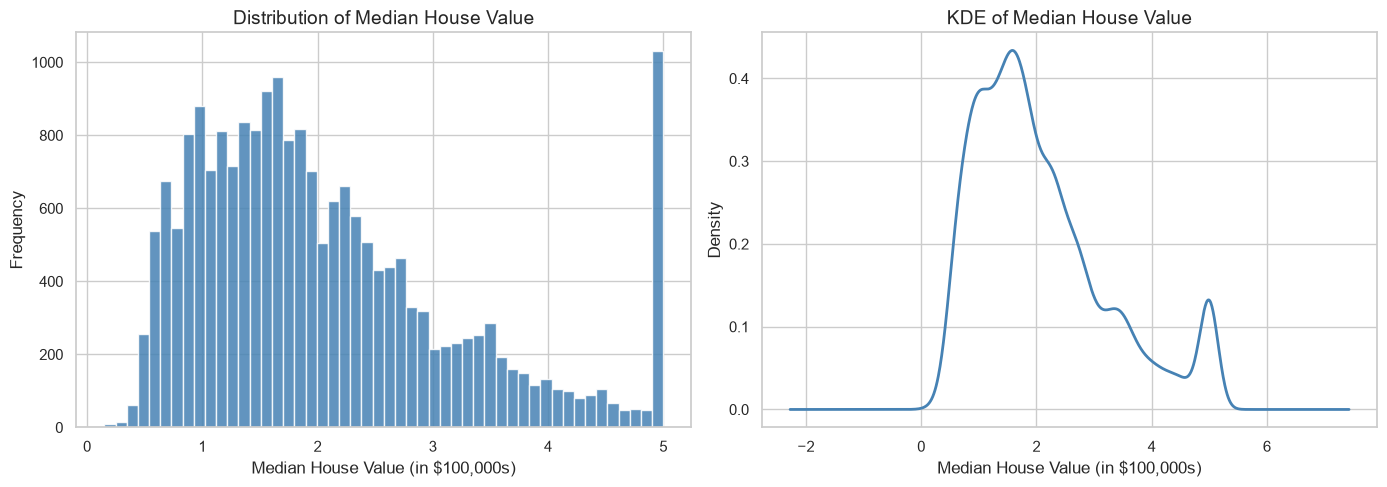


Skewness of HouseValue: 0.9778
Comment: The target variable is positively skewed (right-skewed).
         Most houses are moderately priced; a few expensive properties skew the distribution right.


In [3]:
# A.2 Plot the distribution of the target variable (HouseValue)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['HouseValue'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution of Median House Value')
axes[0].set_xlabel('Median House Value (in $100,000s)')
axes[0].set_ylabel('Frequency')

# KDE plot
df['HouseValue'].plot(kind='kde', ax=axes[1], color='steelblue', linewidth=2)
axes[1].set_title('KDE of Median House Value')
axes[1].set_xlabel('Median House Value (in $100,000s)')

plt.tight_layout()
plt.show()

skewness = df['HouseValue'].skew()
print(f'\nSkewness of HouseValue: {skewness:.4f}')
if skewness > 0.5:
    print('Comment: The target variable is positively skewed (right-skewed).')
    print('         Most houses are moderately priced; a few expensive properties skew the distribution right.')
elif skewness < -0.5:
    print('Comment: The target variable is negatively skewed (left-skewed).')
else:
    print('Comment: The target variable is approximately normally distributed.')


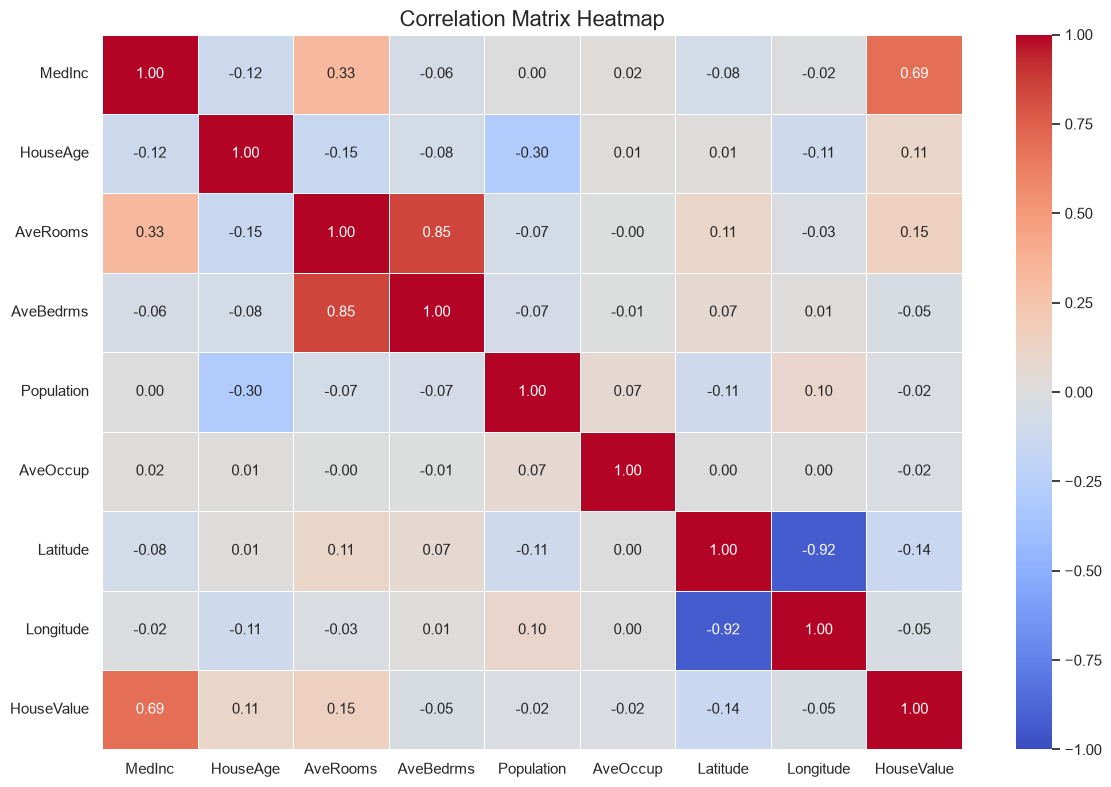


Feature Correlation with HouseValue (sorted):
MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160

Most positively correlated feature: 'MedInc' (0.6881)
Most negatively correlated feature: 'Latitude' (-0.1442)


In [4]:
# A.3 Correlation matrix and heatmap
corr_matrix = df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    center=0,
    vmin=-1,
    vmax=1
)
plt.title('Correlation Matrix Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

target_corr = corr_matrix['HouseValue'].drop('HouseValue').sort_values(ascending=False)
print('\nFeature Correlation with HouseValue (sorted):')
print(target_corr.to_string())
top_pos = target_corr.index[0]
top_neg = target_corr.index[-1]
print(f'\nMost positively correlated feature: {top_pos!r} ({target_corr.iloc[0]:.4f})')
print(f'Most negatively correlated feature: {top_neg!r} ({target_corr.iloc[-1]:.4f})')


## Part B: Simple Linear Regression

We select **MedInc** (Median Income) as the predictor variable since it has the highest positive correlation with house value.

The hypothesis equation is:
$$y = \beta_0 + \beta_1 x + \epsilon$$

Where:
- $y$ = Predicted Median House Value
- $x$ = Median Income (MedInc)
- $\beta_0$ = Intercept
- $\beta_1$ = Slope
- $\epsilon$ = Error term


In [5]:
# B.1 - B.4: Select predictor, split data, fit Simple Linear Regression, report coefficients

# Selected predictor: MedInc (highest correlation with HouseValue)
X_simple = df[['MedInc']]  # 2D array for sklearn
y = df['HouseValue']

# Train-Test Split (80/20)
X_train_s, X_test_s, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

# Fit Simple Linear Regression
slr_model = LinearRegression()
slr_model.fit(X_train_s, y_train)

beta_0 = slr_model.intercept_
beta_1 = slr_model.coef_[0]

print('Simple Linear Regression Results')
print('=' * 40)
print('Predictor Variable : MedInc')
print(f'Intercept (beta_0) : {beta_0:.6f}')
print(f'Slope     (beta_1) : {beta_1:.6f}')
print(f'\nFitted Equation: y = {beta_0:.4f} + {beta_1:.4f} * MedInc')


Simple Linear Regression Results
Predictor Variable : MedInc
Intercept (beta_0) : 0.444597
Slope     (beta_1) : 0.419338

Fitted Equation: y = 0.4446 + 0.4193 * MedInc


C:\Users\Jeetu Mehra\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


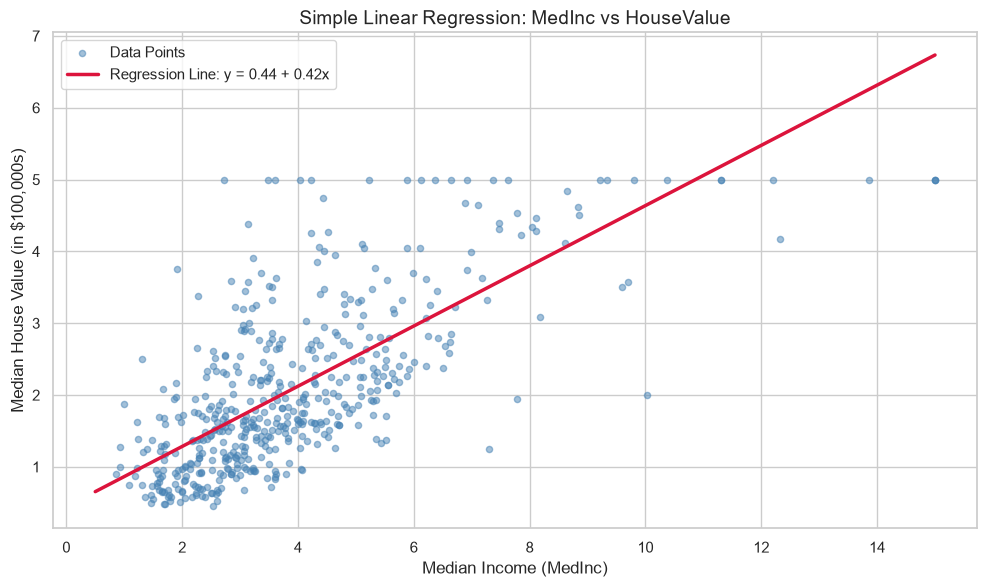


Slope Interpretation:
  A one-unit increase in Median Income (MedInc) is associated with an
  increase of approximately $41,934 in the median house value,
  holding all other factors constant.


In [6]:
# B.5: Scatter plot with regression line
sample = df.sample(500, random_state=42)
x_range = np.linspace(df['MedInc'].min(), df['MedInc'].max(), 200).reshape(-1, 1)
y_range_pred = slr_model.predict(x_range)

plt.figure(figsize=(10, 6))
plt.scatter(sample['MedInc'], sample['HouseValue'], alpha=0.5, color='steelblue', s=20, label='Data Points')
plt.plot(x_range, y_range_pred, color='crimson', linewidth=2.5,
         label=f'Regression Line: y = {beta_0:.2f} + {beta_1:.2f}x')
plt.xlabel('Median Income (MedInc)')
plt.ylabel('Median House Value (in $100,000s)')
plt.title('Simple Linear Regression: MedInc vs HouseValue')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# B.6: Interpret the slope
print('\nSlope Interpretation:')
print(f'  A one-unit increase in Median Income (MedInc) is associated with an')
approx_increase = beta_1 * 100_000
print(f'  increase of approximately ${approx_increase:,.0f} in the median house value,')
print(f'  holding all other factors constant.')


In [7]:
# Evaluate Simple Linear Regression
y_pred_slr = slr_model.predict(X_test_s)

r2_slr   = r2_score(y_test, y_pred_slr)
mse_slr  = mean_squared_error(y_test, y_pred_slr)
rmse_slr = np.sqrt(mse_slr)

print('Simple Linear Regression - Model Evaluation')
print('=' * 45)
print(f'R2 Score : {r2_slr:.6f}')
print(f'MSE      : {mse_slr:.6f}')
print(f'RMSE     : {rmse_slr:.6f}')


Simple Linear Regression - Model Evaluation
R2 Score : 0.458859
MSE      : 0.709116
RMSE     : 0.842090


## Part C: Multiple Linear Regression

We use **all 8 predictor variables** to build a multiple linear regression model.

Selected predictors:
- **MedInc** - Median income
- **HouseAge** - Median house age
- **AveRooms** - Average number of rooms
- **AveBedrms** - Average number of bedrooms
- **Population** - Block population
- **AveOccup** - Average house occupancy
- **Latitude** - Geographic latitude
- **Longitude** - Geographic longitude

The fitted equation takes the form:
$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_n x_n + \epsilon$$


In [8]:
# C.1 & C.2: Select predictors, fit Multiple Linear Regression
feature_cols = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

X_multi = df[feature_cols]

# Train-Test Split (same random state for fair comparison)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.2, random_state=42
)

# Fit Multiple Linear Regression
mlr_model = LinearRegression()
mlr_model.fit(X_train_m, y_train_m)

coefficients = pd.Series(mlr_model.coef_, index=feature_cols)
intercept_mlr = mlr_model.intercept_

print('Multiple Linear Regression Results')
print('=' * 45)
print(f'Intercept (beta_0): {intercept_mlr:.6f}')
print('\nCoefficients:')
for feat, coef in coefficients.items():
    print(f'  {feat:<12}: {coef:>12.6f}')

print('\nFitted Equation:')
eq = f'y = {intercept_mlr:.4f}'
for feat, coef in coefficients.items():
    sign = '+' if coef >= 0 else '-'
    eq += f' {sign} {abs(coef):.4f}*{feat}'
print(f'  {eq}')


Multiple Linear Regression Results
Intercept (beta_0): -37.023278

Coefficients:
  MedInc      :     0.448675
  HouseAge    :     0.009724
  AveRooms    :    -0.123323
  AveBedrms   :     0.783145
  Population  :    -0.000002
  AveOccup    :    -0.003526
  Latitude    :    -0.419792
  Longitude   :    -0.433708

Fitted Equation:
  y = -37.0233 + 0.4487*MedInc + 0.0097*HouseAge - 0.1233*AveRooms + 0.7831*AveBedrms - 0.0000*Population - 0.0035*AveOccup - 0.4198*Latitude - 0.4337*Longitude


Coefficient Interpretation: MedInc
  Coefficient of MedInc = 0.448675
  Interpretation: Holding all other features constant, a one-unit increase
  in Median Income is associated with an increase of ~$44,867 in median house value.


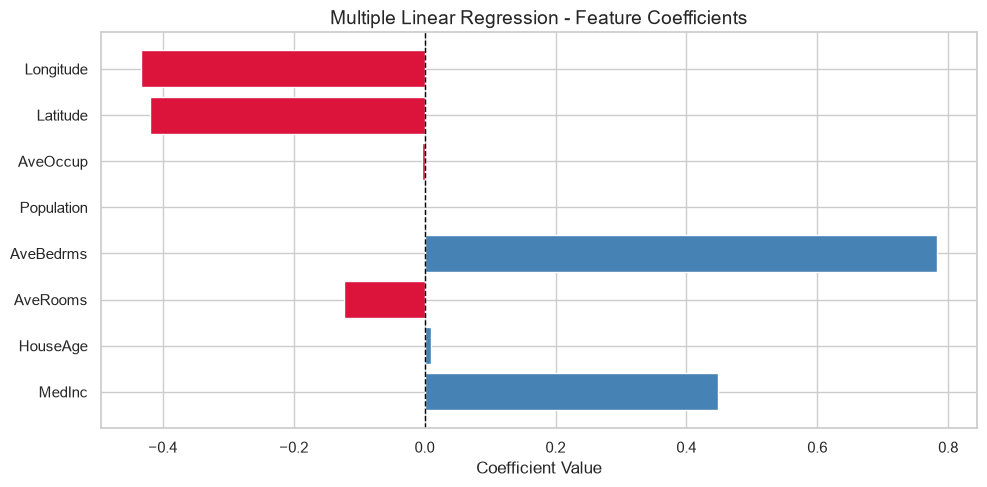

In [9]:
# C.3: Visualize coefficients and interpret MedInc
coef_medinc = coefficients['MedInc']
print('Coefficient Interpretation: MedInc')
print('=' * 45)
print(f'  Coefficient of MedInc = {coef_medinc:.6f}')
print('  Interpretation: Holding all other features constant, a one-unit increase')
approx_increase_mlr = coef_medinc * 100_000
print(f'  in Median Income is associated with an increase of ~${approx_increase_mlr:,.0f} in median house value.')

# Visualize all coefficients
plt.figure(figsize=(10, 5))
colors = ['steelblue' if c >= 0 else 'crimson' for c in coefficients.values]
plt.barh(coefficients.index, coefficients.values, color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=1, linestyle='--')
plt.xlabel('Coefficient Value')
plt.title('Multiple Linear Regression - Feature Coefficients')
plt.tight_layout()
plt.show()


Multiple Linear Regression - Model Evaluation
R2 Score : 0.575788
MSE      : 0.555892
RMSE     : 0.745581


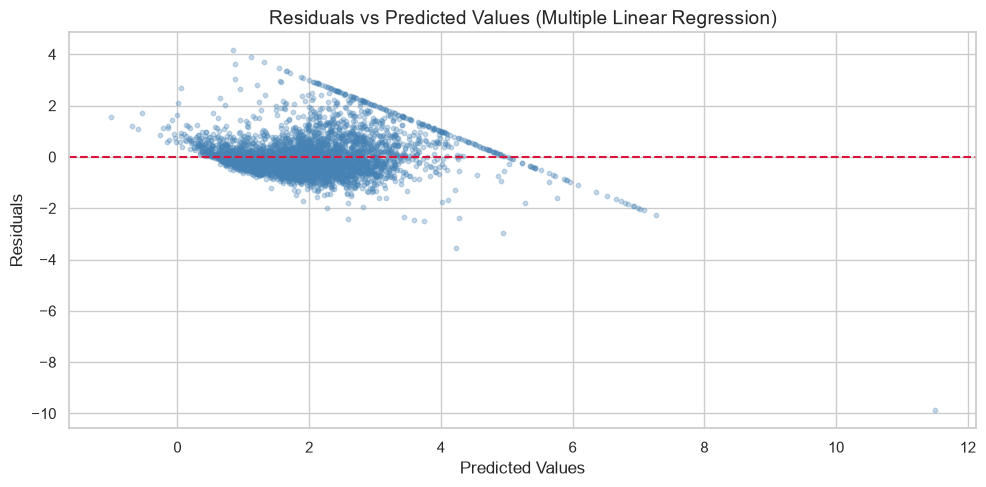

In [10]:
# C.4: Evaluate Multiple Linear Regression
y_pred_mlr = mlr_model.predict(X_test_m)

r2_mlr   = r2_score(y_test_m, y_pred_mlr)
mse_mlr  = mean_squared_error(y_test_m, y_pred_mlr)
rmse_mlr = np.sqrt(mse_mlr)

print('Multiple Linear Regression - Model Evaluation')
print('=' * 45)
print(f'R2 Score : {r2_mlr:.6f}')
print(f'MSE      : {mse_mlr:.6f}')
print(f'RMSE     : {rmse_mlr:.6f}')

# Residuals plot
residuals = y_test_m - y_pred_mlr
plt.figure(figsize=(10, 5))
plt.scatter(y_pred_mlr, residuals, alpha=0.3, color='steelblue', s=10)
plt.axhline(0, color='crimson', linewidth=1.5, linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values (Multiple Linear Regression)')
plt.tight_layout()
plt.show()


Model Comparison: Simple vs Multiple Linear Regression
                   Model  R2 Score      MSE     RMSE  Num Features
 Simple LR (MedInc only)  0.458859 0.709116 0.842090             1
Multiple LR (8 features)  0.575788 0.555892 0.745581             8


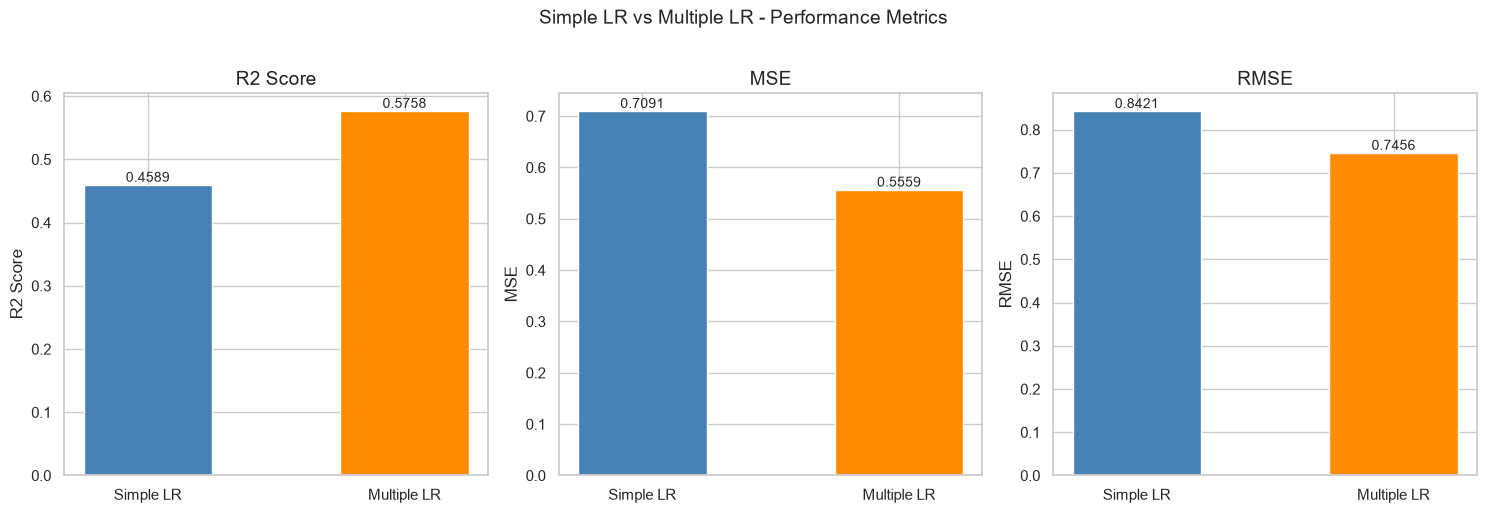


Conclusion:
  Multiple Linear Regression achieves R2=0.5758 vs Simple LR R2=0.4589.
  The Multiple LR model has a significantly higher R2 and lower MSE/RMSE,
  indicating it explains more variance in house prices by leveraging 8 features.
  Therefore, Multiple Linear Regression is the better model for this dataset.


In [11]:
# C.5: Compare Simple vs Multiple Linear Regression
print('Model Comparison: Simple vs Multiple Linear Regression')
print('=' * 60)
comparison_df = pd.DataFrame({
    'Model': ['Simple LR (MedInc only)', 'Multiple LR (8 features)'],
    'R2 Score': [round(r2_slr, 6), round(r2_mlr, 6)],
    'MSE': [round(mse_slr, 6), round(mse_mlr, 6)],
    'RMSE': [round(rmse_slr, 6), round(rmse_mlr, 6)],
    'Num Features': [1, 8]
})
print(comparison_df.to_string(index=False))

# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics_labels = ['R2 Score', 'MSE', 'RMSE']
slr_vals = [r2_slr, mse_slr, rmse_slr]
mlr_vals = [r2_mlr, mse_mlr, rmse_mlr]
colors_pair = ['steelblue', 'darkorange']

for ax, metric, sv, mv in zip(axes, metrics_labels, slr_vals, mlr_vals):
    bars = ax.bar(['Simple LR', 'Multiple LR'], [sv, mv], color=colors_pair, edgecolor='white', width=0.5)
    ax.set_title(metric)
    ax.set_ylabel(metric)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
                f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Simple LR vs Multiple LR - Performance Metrics', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('\nConclusion:')
print(f'  Multiple Linear Regression achieves R2={r2_mlr:.4f} vs Simple LR R2={r2_slr:.4f}.')
print(f'  The Multiple LR model has a significantly higher R2 and lower MSE/RMSE,')
print(f'  indicating it explains more variance in house prices by leveraging 8 features.')
print(f'  Therefore, Multiple Linear Regression is the better model for this dataset.')
